In [2]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
import matplotlib as mpl                                                                # type: ignore
from joblib import dump, load                                                           # type: ignore

In [43]:
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 12}

mpl.rc('font', **font)

axis_font = {'family': 'serif',
             'color':  'black',
             'weight': 'normal',
             'size': 11,
            }

### Importing dataset

In [4]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [5]:
path_pcX0 = "/home/mendrika/mendrika-phd/data/pcX0-Dakar-lead-times"

In [6]:
data_pcX0 = nflics.all_files_in(path_pcX0)
data_pcX0.sort()

In [7]:
data_pcX0 = nflics.all_files_in(path_pcX0)
data_pcX0.sort()
list_data = []
for i in data_pcX0:
    pc_X0_t0 = pd.read_csv(i, index_col=False)
    list_data.append(pc_X0_t0)
df_data_pcX0 = pd.concat(list_data)

In [8]:
df_data_pcX0

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,ds2,ds3,ds4,ds5,Cb_Dakar_t1,Cb_Dakar_t3,Cb_Dakar_t6,pc_nflics_t1,pc_nflics_t3,pc_nflics_t6
0,2020,6,1,0,0,11.32,-16.08,10.11,-15.77,11.37,...,123.66,167.44,430.00,430.00,0.0,0.0,0.0,0.06,0.05,0.08
1,2020,6,6,0,0,12.67,-9.03,10.29,-11.01,12.67,...,287.47,293.00,326.94,336.48,0.0,0.0,0.0,0.04,0.04,0.05
2,2020,6,8,0,0,12.22,-13.03,12.13,-15.00,12.85,...,99.20,116.50,117.03,167.22,0.0,0.0,0.0,0.07,0.08,0.12
3,2020,6,10,0,0,14.15,-12.94,13.21,-13.21,12.13,...,152.95,156.16,169.01,170.07,0.0,0.0,0.0,0.08,0.10,0.12
4,2020,6,12,0,0,10.33,-9.97,10.56,-9.48,14.00,...,302.00,430.00,430.00,430.00,0.0,0.0,0.0,0.05,0.03,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,2022,9,25,23,0,13.93,-13.66,12.89,-15.14,13.52,...,95.78,129.44,430.00,430.00,0.0,0.0,0.0,0.00,0.00,0.00
253,2022,9,26,23,0,13.88,-9.70,14.38,-10.06,14.56,...,264.19,279.00,430.00,430.00,0.0,0.0,0.0,0.00,0.00,0.00
254,2022,9,27,23,0,11.28,-15.41,11.05,-15.18,11.23,...,144.06,150.00,430.00,430.00,0.0,0.0,0.0,0.00,0.00,0.00
255,2022,9,28,23,0,12.85,-16.44,12.98,-14.24,10.96,...,111.99,119.08,149.59,156.01,0.0,0.0,0.0,0.00,0.00,0.00


In [9]:
hour_min = "00"
hour_max = "24"

query = f"{nflics.format(hour_min)} <= `hour`< {nflics.format(hour_max)} and `minute`=={nflics.format('00')}"
raw_test_data = df_data_pcX0.query(query).reset_index(drop=True)


#### combining dataset and doing some exploratory analysis

#### Choosing field to include in the data

In [10]:
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features.split(',')

### Exploratory data analysis

In [11]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [12]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [13]:
to_scale = wavelet_power + storm_size + distance

In [14]:
raw_test_data = raw_test_data.dropna()
transform = True
if transform:    
    transformed_test_data = log_transform(raw_test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(transformed_test_data, t0.split(',')[:-1])    

In [15]:
y_test_t1 = test_data["Cb_Dakar_t1"].to_numpy()
y_test_t3 = test_data["Cb_Dakar_t3"].to_numpy()
y_test_t6 = test_data["Cb_Dakar_t6"].to_numpy()

In [16]:
x_test = test_data.drop(["Cb_Dakar_t1", "Cb_Dakar_t3", "Cb_Dakar_t6", "pc_nflics_t1", "pc_nflics_t3", "pc_nflics_t6"], axis=1)

In [17]:
model_t1 = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t1.keras")
model_t3 = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t3.keras")
model_t6 = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t6.keras")

In [18]:
scaler = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Dakar-t1.bin')

In [19]:
x_test_std = scaler.transform(x_test)

/home/mendrika/.local/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [20]:
def class_prediction(model, x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [21]:
def plot_cm(y, y_hat, classification_threshold):     
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

### Performance on testing data

In [22]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

In [23]:
y_test_pred_t1, auc_test_t1, bs_test_t1 = class_prediction(model_t1, x_test_std, y_test_t1)
y_test_pred_t3, auc_test_t3, bs_test_t3 = class_prediction(model_t3, x_test_std, y_test_t3)
y_test_pred_t6, auc_test_t6, bs_test_t6 = class_prediction(model_t6, x_test_std, y_test_t6)

152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [24]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

In [25]:
prob_pred_t1, prob_true_t1, no_pred_per_bin_t1 = reliability_curve(y_test_t1, y_test_pred_t1.flatten())
prob_pred_t3, prob_true_t3, no_pred_per_bin_t3 = reliability_curve(y_test_t3, y_test_pred_t3.flatten())
prob_pred_t6, prob_true_t6, no_pred_per_bin_t6 = reliability_curve(y_test_t6, y_test_pred_t6.flatten())

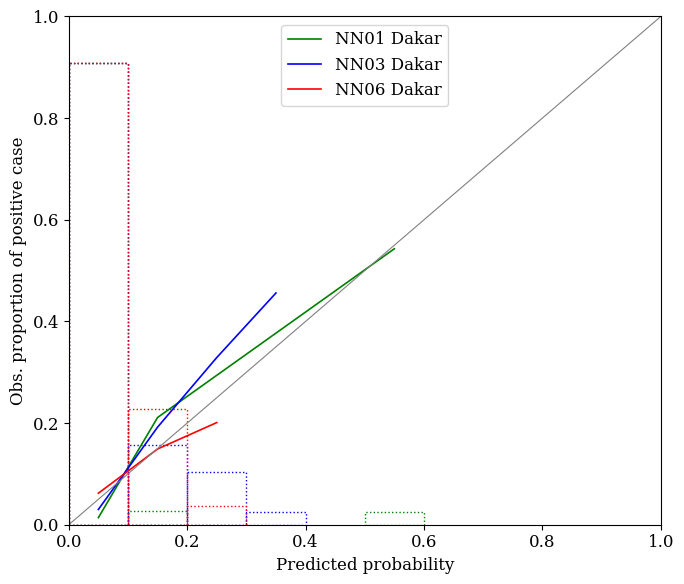

In [44]:
plt.figure(figsize=(7, 6))

plt.plot(prob_pred_t1, prob_true_t1, label=f"NN01 Dakar", color="green", linewidth=1.2)    
plt.plot(prob_pred_t3, prob_true_t3, label=f"NN03 Dakar", color="blue", linewidth=1.2)
plt.plot(prob_pred_t6, prob_true_t6, label=f"NN06 Dakar", color="red", linewidth=1.2)


no_pred_per_bin_t1 = [i/(1.1*np.max(no_pred_per_bin_t1)) for i in no_pred_per_bin_t1]
no_pred_per_bin_t3 = [i/(1.1*np.max(no_pred_per_bin_t3)) for i in no_pred_per_bin_t3]
no_pred_per_bin_t6 = [i/(1.1*np.max(no_pred_per_bin_t6)) for i in no_pred_per_bin_t6]


plt.plot(np.arange(0, 1.2, 0.2), np.arange(0, 1.2, 0.2), color="gray", linewidth=0.8)

plt.bar(prob_pred_t1, no_pred_per_bin_t1, width=0.1, linestyle=":", fill=False, edgecolor="green")
plt.bar(prob_pred_t3, no_pred_per_bin_t3, width=0.1, linestyle=":", fill=False, edgecolor="blue")
plt.bar(prob_pred_t6, no_pred_per_bin_t6, width=0.1, linestyle=":", fill=False, edgecolor="red")


plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")
plt.legend(loc='upper center')
plt.tight_layout()
plt.show()

In [27]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)  
  plt.plot(100*fp, 100*tp, label=name, linewidth=1.2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,101])
  plt.ylim([0,101])
  plt.grid(True, linewidth=0.3)
  ax = plt.gca()
  ax.set_aspect('equal')
  plt.tight_layout()

/tmp/ipykernel_5394/218660184.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_5394/218660184.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_5394/218660184.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_5394/218660184.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_5394/218660184.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


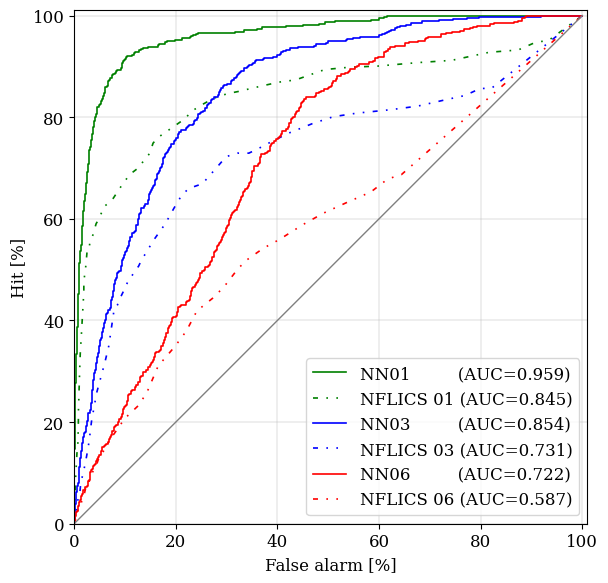

In [45]:
mpl.rcParams['figure.figsize'] = (7,6)

y_nflics_t1 = test_data["pc_nflics_t1"]
y_nflics_t3 = test_data["pc_nflics_t3"]
y_nflics_t6 = test_data["pc_nflics_t6"]

auc_nflics_t1 = roc_auc_score(y_test_t1, y_nflics_t1)
auc_nflics_t3 = roc_auc_score(y_test_t3, y_nflics_t3)
auc_nflics_t6 = roc_auc_score(y_test_t6, y_nflics_t6)


plot_roc(f"NN01         (AUC={auc_test_t1:.3f})", y_test_t1, y_test_pred_t1, color="green", linestyle="-")
plot_roc(f"NFLICS 01 (AUC={auc_nflics_t1:.3f})", y_test_t1, y_nflics_t1, color="green", linestyle=(0, (3, 5, 1, 5, 1, 5)))

plot_roc(f"NN03         (AUC={auc_test_t3:.3f})", y_test_t3, y_test_pred_t3, color="blue")
plot_roc(f"NFLICS 03 (AUC={auc_nflics_t3:.3f})", y_test_t3, y_nflics_t3, color="blue", linestyle=(0, (3, 5, 1, 5, 1, 5)))

plot_roc(f"NN06         (AUC={auc_test_t6:.3f})", y_test_t6, y_test_pred_t6, color="red")
plot_roc(f"NFLICS 06 (AUC={auc_nflics_t6:.3f})", y_test_t6, y_nflics_t6, color="red", linestyle=(0, (3, 5, 1, 5, 1, 5)))

plt.plot(np.arange(0,1.2,0.2)*100, np.arange(0,1.2,0.2)*100, color="gray", linewidth=1)

plt.legend(loc='lower right');

In [30]:
def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = metrics.precision_recall_curve(labels, predictions)
    plt.plot(precision, recall, label=name, linewidth=2, **kwargs)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.grid(True)
    ax = plt.gca()
    ax.set_aspect('equal')

In [31]:
bs_nflics_t1 = brier_score_loss(y_test_t1, y_nflics_t1)
bs_nflics_t3 = brier_score_loss(y_test_t3, y_nflics_t3)
bs_nflics_t6 = brier_score_loss(y_test_t6, y_nflics_t6)

In [32]:
bs_nn_t1 = brier_score_loss(y_test_t1, y_test_pred_t1)
bs_nn_t3 = brier_score_loss(y_test_t3, y_test_pred_t3)
bs_nn_t6 = brier_score_loss(y_test_t6, y_test_pred_t6)

In [33]:
bss_t1 = 1 - bs_nn_t1 / bs_nflics_t1
bss_t3 = 1 - bs_nn_t3 / bs_nflics_t3
bss_t6 = 1 - bs_nn_t6 / bs_nflics_t6

In [34]:
print(round(bss_t1, 2), round(bss_t3, 2), round(bss_t6, 2))

0.39 0.11 0.07


In [35]:
window = ["00:00 - 05:00", "06:00 - 11:00", "12:00 - 17:00", "18:00 - 23:00"]
BSS_1 = [0.35, 0.38, 0.47, 0.4]
BSS_3 = [0.04, 0.04, 0.06, 0.2]
BSS_6 = [0.09, 0.05, 0.03, 0.12]

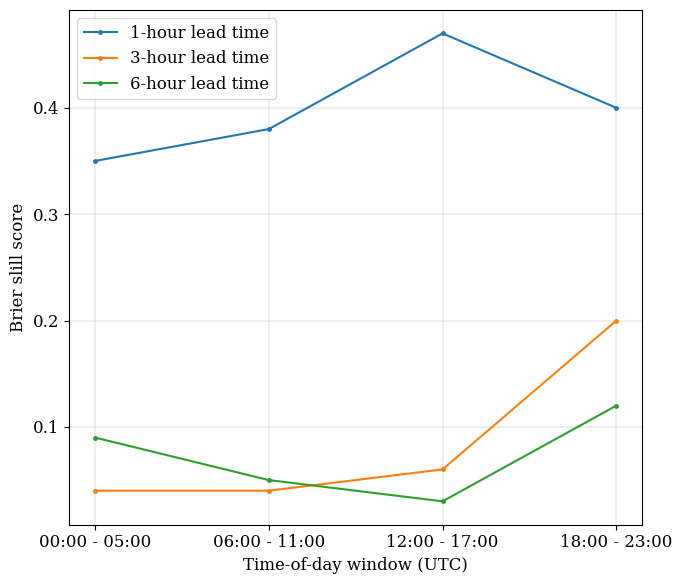

In [46]:
mpl.rcParams['figure.figsize'] = (7,6)

plt.plot(window, BSS_1, label = "1-hour lead time", marker=".", markersize=5)
plt.plot(window, BSS_3, label = "3-hour lead time", marker=".", markersize=5)
plt.plot(window, BSS_6, label = "6-hour lead time", marker=".", markersize=5)
plt.legend()
#plt.xticks(rotation=45)
plt.xlabel("Time-of-day window (UTC)")
plt.ylabel("Brier slill score")
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()